# Introduction to Machine Learning: Illustrated Principles
## Notebook to accompany Chapter 6: Features, Regularization, and Validation

<div class="alert alert-success" style="border-left: 5px solid #28a745;">
    
### **SOLUTIONS**

## Overview

This notebook set deals with the [Ames housing dataset](https://jse.amstat.org/v19n3/decock/AmesHousing.xls).

The goal is to use validation to select which features to use and the proper regularization strength, for predicting the selling price of house.

In [1]:
## These are the only libraries you should need
import numpy as np
import matplotlib.pyplot as plt

# below line just to make figures larger
#plt.rcParams["figure.figsize"] = (20,10)

### Dataset
The dataset consists of features of a house and the price at which the house sold.  Each data point is a house.  The label, $y$, is the selling price of the house, in thousands of dollars.  The data has been modified for this problem:
- A few outliners have been removed.
- Categorical variables have been removed.
- Features with missing values have been removed.
- The data have been split randomly into training and testing data.

The code below loads in both a training dataset (`train`) and a testing dataset (`test`).  Each has a `.X` and `.Y` field: numpy arrays of the $X$ and $Y$ matrices.  You can view the names of the features as `train.featnames`.

In [2]:
import sys; sys.path.insert(0, '../..') # path to dataset.py (adjust if you have moved this file or dataset.py)
from dataset import loaddataset

#adjust the directory below if you have moved either the dataset files or this notebook
datasetdir = '../../datasets/' 

train = loaddataset(datasetdir+'ameshousing-cont-train')
test = loaddataset(datasetdir+'ameshousing-cont-test')

### Data Pre-processing
As common, we will first do z-score normalization (see the previous notebook or chapter 9): replace each feature with the number of standard deviations the raw feature is from the mean in the trainging test.  Treat these new X matrices as the "raw features" for the purposes below.

In [3]:
# z-score normalization:
featuremeans = np.mean(train.X,axis=0)
featurestd = np.std(train.X,axis=0)
train.X = (train.X-featuremeans)/featurestd
test.X = (test.X-featuremeans)/featurestd

### Base Learning Methods

Below are the functions to learn and predict for regularized linear least squares and logistic regression.  These will be used for Question 1 and Question 2 (respectively).  You could easily write them on your own, making small modifications to the same routines in previous notebooks.  However, the emphasis of this notebook is elsewhere.

In [4]:
def learnlls(X,Y,regstr=0.0):
    # LLS with regstr=0.0.  Ridge regression with regstr>0.  lambda=regstr
    # X is shape (m,n), Y is shape (m,).  Returns weights of shape (n,)
    from sklearn.linear_model import Ridge, LinearRegression
    if regstr==0.0: # Ridge was not designed to work with regstr=0.0
        return LinearRegression(fit_intercept=False).fit(X,Y).coef_
    else:
        return Ridge(alpha=regstr,fit_intercept=False).fit(X,Y).coef_
def predlls(X,w):
    return X@w

def learnlogreg(X,Y,regstr=0.0):
    # logistic regression with regstr=0.0.  logistic regression with L2 regulatization with regstr>0.  lambda=regstr
    # X is shape (m,n), Y is shape (m,) and has values of +1/-1.  Returns weights of shape (n,)
    from sklearn.linear_model import LogisticRegression
    if regstr==0.0:
        m = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000).fit(X,Y)
    else:
        m = LogisticRegression(penalty='l2', solver='liblinear', C=1.0/regstr, fit_intercept=False, max_iter=10000).fit(X,Y)
    return m.coef_[0,:]
    
def predlogreg(X,w):
    return np.sign(X@w)

## Question 1: **Regression**
---
> ### Cross-validation for choice of features
>
> Compare different sets of constructed features.  Consider three sets of possible extra features to add:
> - **A** indicators: one feature for each of the raw features.  The feature is 1 if the raw feature is >0 and 0 otherwise.
> - **B** squares: one feature for each of the raw features.  The feature is the square of the raw feature.
> - **C** abs: one feature for each of the raw features.  The feature is the absolute value of the raw feature.
>   
> Consider all $2^3=8$ possibilities for adding or not adding each of these feature sets: no added features, only the A features, only the B features, both the A and B features, ...  For each of these $8$ sets of features, also include the "constant feature" (of all 1s).
> 
> **part a** For each of these $8$ sets of features, use 5-fold cross-validation to score the feature set.  Pick the best set of features and report the testing error on this set.  Use mean square error.
>
> *Note*: the training data has already been shuffled, so you do not need to permute/shuffle it for splitting for cross-validation.
---

In [5]:
def testlls(X,Y,w):
    # X and Y are the testing data
    # w are the weights from linear least-squares regression
    # returns the root mean squared error (that is, the square root of the average squared error)
    Ydelta = Y - predlls(X,w)
    return np.sqrt((Ydelta*Ydelta).mean())

def xvalid(trainfn, testfn, X,Y,k=5):
    allind = np.arange(X.shape[0])
    foldinds = np.array_split(allind,k)
    totalerr = 0
    for validind in foldinds:
        trainind = np.setdiff1d(allind,validind)
        w = trainfn(X[trainind],Y[trainind])
        totalerr += testfn(X[validind],Y[validind],w)*len(validind)
    return totalerr/X.shape[0]

#------------------
    
def addfeatures(f1,*args):
    if len(args)==0:
        return lambda X: np.hstack((X,f1(X)))
    else:
        return lambda X: np.hstack((addfeatures(*args)(X),f1(X)))

def indicators(X):
    return X>0

def constant(X):
    return np.ones((X.shape[0],1))
    
def squares(X):
    return X*X

def logs(X):
    return np.log(np.abs(X)+1)

def abss(X):
    return np.abs(X)

def powerset(x):
    from itertools import chain, combinations
    s = list(x)
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

feats = [ (addfeatures(constant,*[x[0] for x in ps]),'raw X + '+(', '.join([x[1] for x in ps])))
           for ps in powerset([
                    (indicators,'A'),
                    (squares,'B'),
                    (abss,'C'),
                   ])]

#------------------

best = None
print('cross-validation errors:')
for fn,fname in feats:
    err = xvalid(learnlls, testlls, fn(train.X), train.Y,5)
    print(f'\t{fname:<20}: {err:3.4}')
    if best is None or best[0]>err:
        best = (err,fn,fname)

besterr,bestfeatfn,bestfeatname = best
print(f'cross-validation picks {bestfeatname}')
w = learnlls(bestfeatfn(train.X),train.Y)
tsterr = testlls(bestfeatfn(test.X),test.Y,w)
print(f'testing error: {tsterr:3.4}')        

cross-validation errors:
	raw X +             : 24.44
	raw X + A           : 23.33
	raw X + B           : 20.75
	raw X + C           : 20.0
	raw X + A, B        : 21.21
	raw X + A, C        : 19.99
	raw X + B, C        : 21.25
	raw X + A, B, C     : 21.25
cross-validation picks raw X + A, C
testing error: 21.88


---
> **part b** Consider using ridge regression (l2-regularized linear least squares).  Use 5-fold cross-validation to pick both which feature set to use (from the same set of 8) and what value of lambda (the regularization strength) to use.
>
> On one plot, plot the cross-validation error versus lambda for each of the eight feature sets.  Place a circle at the point chosen by cross-validation.  Use a log-scale for the horizontal axis (lambda).
>
> *Hint*: Try lambda values between $10^{-2}$ and $10^{2}$ on a log scale.

cross-validation selects raw X + A, C with lambda=1.274: 19.89


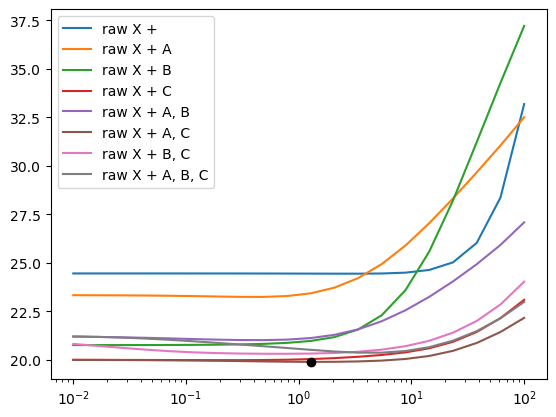

In [6]:
nlambda = 20
validerr = np.zeros((nlambda,len(feats)))
ls = np.logspace(-2,2,nlambda)
best = None
for i,l in enumerate(ls):
    for j,(fn,fnames) in enumerate(feats):
        validerr[i,j] = xvalid(lambda X,Y : learnlls(X,Y,l) ,testlls, fn(train.X), train.Y, 5)
        if best is None or validerr[i,j]<best[0]:
            best = (validerr[i,j],l,fn,fnames,i,j)

print(f'cross-validation selects {best[3]} with lambda={best[1]:3.4}: {best[0]:3.4}')

for j,(fn,fnames) in enumerate(feats):
    plt.semilogx(ls,validerr[:,j],label=fnames)
plt.semilogx(ls[best[4]],best[0],'ko',label=None)
plt.legend();
        

---
> **part c** Report the testing error for the chosen combination of features and lambda.
---

In [7]:
featfn = best[2]
regstr = best[1]
w = learnlls(featfn(train.X),train.Y,regstr)
errrate = testlls(featfn(test.X),test.Y,w)
print(f'testing error rate: {errrate:3.4}')

testing error rate: 21.47


## Question 2:

We will now do the same, but for classification.  Our binary classification problem is to predict whether the price is greater than \\$150k.  The code below constructs the variables `trainYclass` and `testYclass` which should be used instead of `train.Y` and `test.Y`  The values in these new vectors are -1 if the price is less than or equal to \\$150k and +1 is the price is greater than \$150k.\

In [8]:
trainYclass = (train.Y>150)*2-1
testYclass = (test.Y>150)*2-1
#trainYclass = train.Y>150
#testYclass = test.Y>150

---
> **part a** Do the same as in part b of Question 1, but for logistic regression for classification:
>
> Plot the 5-fold cross-validation classification error rate as a function of lambda for each of the $8$ feature sets use in Question 1.
>
> State which combination of lambda and features is chosen by cross-validation.

In [9]:
def testlogreg(X,Y,w):
    # X and Y are the testing data
    # w are the weights from logistic regression
    # returns the mean squared error
    Ypred = np.sign(predlogreg(X,w)) ## should be +1/-1, but in case they are not
    
    return (Ypred!=np.sign(Y)).mean()

cross-validation selects raw X + C with lambda=18.42: 0.08451


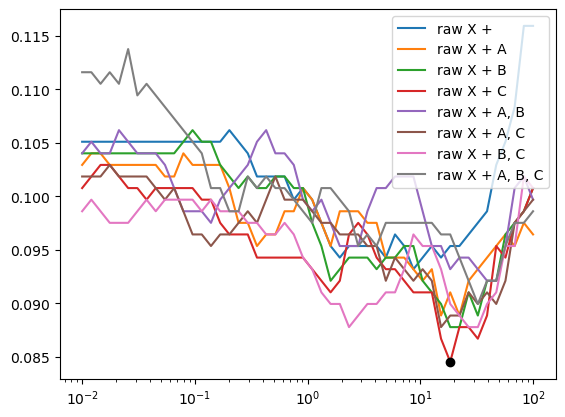

In [10]:
nlambda = 50
validerr = np.zeros((nlambda,len(feats)))
ls = np.logspace(-2,2,nlambda)
best = None
for i,l in enumerate(ls):
    for j,(fn,fnames) in enumerate(feats):
        validerr[i,j] = xvalid(lambda X,Y : learnlogreg(X,Y,l) ,testlogreg, fn(train.X), trainYclass, 5)
        if best is None or validerr[i,j]<best[0]:
            best = (validerr[i,j],l,fn,fnames,i,j)

print(f'cross-validation selects {best[3]} with lambda={best[1]:3.4}: {best[0]:3.4}')

for j,(fn,fnames) in enumerate(feats):
    plt.semilogx(ls,validerr[:,j],label=fnames)
plt.semilogx(ls[best[4]],best[0],'ko',label=None)
plt.legend();

---
> **part b** Report the testing error for the chosen combination of features and lambda.
---

In [11]:
classfeatfn = best[2]
classregstr = best[1]
w = learnlls(classfeatfn(train.X),trainYclass,classregstr)
errrate = testlogreg(classfeatfn(test.X),testYclass,w)
print(f'testing error rate: {errrate:3.4}')

testing error rate: 0.08658
